In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df = pd.read_csv("ai_student_impact_dataset.csv")
y = df["Burnout_Risk_Level"]
X = df.drop(columns="Burnout_Risk_Level")


In [17]:

from sklearn.model_selection import train_test_split

# Separizziamo X (le feature) e y (il target, es. 'Burnout_Risk_Level')
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2,          # Scegliamo il 20% dei dati per il test set e l'80% per il train   
    random_state=42,        # Inseriamo un seme casuale fisso per rendere i risultati riproducibili
    stratify=y              # FONDAMENTALE: Mantiene le stesse proporzioni delle classi del target sia in train che in test
)

target_map = {'Low': 0, 'Medium': 1, 'High': 2}   # random forest e xgboost lavorano meglio se y è mappata
y_train = y_train.map(target_map)
y_test = y_test.map(target_map)

In [18]:
X_train.drop(columns=['Student_ID'], inplace=True, errors='ignore')
X_test.drop(columns=['Student_ID'], inplace=True, errors='ignore') # colonna inutile

mappa_skills = {'Beginner': 1, 'Intermediate': 2, 'Advanced': 3}   #lable encoding risponde alla presenza di un ordinamento
X_train['Prompt_Engineering_Skill_Num'] = X_train['Prompt_Engineering_Skill'].map(mappa_skills)
X_test['Prompt_Engineering_Skill_Num'] = X_test['Prompt_Engineering_Skill'].map(mappa_skills)

X_train = X_train.drop('Prompt_Engineering_Skill_Num', axis=1)
X_test = X_test.drop('Prompt_Engineering_Skill_Num', axis=1)

In [19]:
X_train.drop(columns=['Primary_Use_Case'], inplace=True, errors='ignore')
X_test.drop(columns=['Primary_Use_Case'], inplace=True, errors='ignore')

X_train.drop(columns=['Major_Category'], inplace=True, errors='ignore')
X_test.drop(columns=['Major_Category'], inplace=True, errors='ignore')

X_train.drop(columns=['Institutional_Policy'], inplace=True, errors='ignore')
X_test.drop(columns=['Institutional_Policy'], inplace=True, errors='ignore')


In [20]:
X_train.drop(columns=['Tool_Diversity'], inplace=True, errors='ignore')
X_test.drop(columns=['Tool_Diversity'], inplace=True, errors='ignore')

In [21]:
X_train.drop(columns=['Prompt_Engineering_Skill'], inplace=True, errors='ignore')
X_test.drop(columns=['Prompt_Engineering_Skill'], inplace=True, errors='ignore')

In [22]:

X_test.info()   # Perceived_AI_Dependency- Tool_Diversity    /     Institutional_Policy  ( **dove è bannata** prodotto di ore ai - Anxiety_Level_During_Exams - Paid_Subscription )  / 

<class 'pandas.DataFrame'>
Index: 10000 entries, 18437 to 43395
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Year_of_Study               10000 non-null  str    
 1   Pre_Semester_GPA            10000 non-null  float64
 2   Weekly_GenAI_Hours          10000 non-null  float64
 3   Paid_Subscription           10000 non-null  bool   
 4   Traditional_Study_Hours     10000 non-null  float64
 5   Perceived_AI_Dependency     10000 non-null  int64  
 6   Anxiety_Level_During_Exams  10000 non-null  int64  
 7   Post_Semester_GPA           10000 non-null  float64
 8   Skill_Retention_Score       10000 non-null  float64
dtypes: bool(1), float64(5), int64(2), str(1)
memory usage: 712.9 KB


In [23]:
X_test.describe()

,Pre_Semester_GPA,Weekly_GenAI_Hours,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,3.143922,8.379751,11.169969,3.490800,4.276000,3.346239,75.950446
std,0.481361,8.174937,5.150600,1.815005,2.152182,0.498241,13.254755
min,1.183000,0.000000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,2.830000,2.390000,7.510000,2.000000,3.000000,3.021000,67.200000
50%,3.202500,5.870000,11.090000,3.000000,4.000000,3.411000,76.140000
75%,3.524000,11.660000,14.670000,5.000000,6.000000,3.751000,85.252500
max,3.987000,40.000000,29.950000,10.000000,10.000000,4.000000,100.000000


scelgo di fare target encoding sulla colonna "Year_of_Study", in funzione delle osservazioni in fase di analisi data.
RECAP da analisi dati:
I Freshman (1) iniziano con un livello di burnout alto (il rosso sfiora il 28%). Questo è fisiologico e descrive lo shock da inserimento universitario, le prime sessioni d'esame e il cambio di metodo di studio.

Nei Sophomore (2) e ancora di più nei Junior (3), la fascia rossa si restringe visibilmente, toccando il punto più basso (sotto il 20%). Parallelamente, nei Junior la fascia verde (Low) raggiunge la sua massima espansione (oltre il 40%).

La fascia rossa (High) torna a espandersi, superando nuovamente il 20%.

In [24]:
# 1. Creiamo una copia temporanea del train per calcolare le frequenze
df_temp = X_train.copy()
df_temp['target_temp'] = y_train

# 2. Calcoliamo la tabella delle probabilità per ogni anno di studio
prob_table = pd.crosstab(df_temp['Year_of_Study'], df_temp['target_temp'], normalize='index')
prob_table.columns = [f'Year_of_Study_Prob_{classe}' for classe in prob_table.columns]

# 3. Mappiamo le probabilità creando i nuovi DataFrame codificati
X_train_encoded = X_train.merge(prob_table, on='Year_of_Study', how='left').set_index(X_train.index)
X_test_encoded = X_test.merge(prob_table, on='Year_of_Study', how='left').set_index(X_test.index)

# 4. Gestione di eventuali valori mancanti nel Test Set
for col in prob_table.columns:
    # Rimuoviamo il prefisso per trovare il nome originale della classe (es. 0, 1, 2 oppure 'Low', 'Medium', 'High')
    nome_classe_originale = col.replace('Year_of_Study_Prob_', '')
    
    # Se le classi in y_train sono diventate numeriche (0, 1, 2) a causa di un mapping precedente,
    # convertiamo il nome della classe in intero se è composto da sole cifre
    if str(nome_classe_originale).isdigit():
        nome_classe_originale = int(nome_classe_originale)
        
    prob_globale = (y_train == nome_classe_originale).mean()
    X_test_encoded[col] = X_test_encoded[col].fillna(prob_globale)

# ==============================================================================
# 5. PASSO FONDAMENTALE: AGGIORNARE LE VARIABILI ORIGINALI E RIMUOVERE LA VECCHIA COLONNA
# ==============================================================================
# Sovrascriviamo X_train e X_test con i nuovi DataFrame che contengono le probabilità
X_train = X_train_encoded.copy()
X_test = X_test_encoded.copy()


In [25]:
# 5. Eliminiamo la vecchia colonna categorica 'Year_of_Study' se presente
if 'Year_of_Study' in X_train.columns:
    X_train.drop(columns=['Year_of_Study'], inplace=True)
if 'Year_of_Study' in X_test.columns:
    X_test.drop(columns=['Year_of_Study'], inplace=True)

# Verifica finale per essere sicuri al 100%
print("Colonne create con successo:")
print([c for c in X_train.columns if 'Year_of_Study_Prob' in c])

Colonne create con successo:
['Year_of_Study_Prob_0', 'Year_of_Study_Prob_1', 'Year_of_Study_Prob_2']


In [26]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. La PCA è sensibile alle scale, quindi standardizziamo prima le feature
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Inizializziamo la PCA chiedendo di mantenere, ad esempio, solo 3 componenti principali
pca = PCA(n_components=9, random_state=42)

# 3. Trasformiamo i nostri dataset enormi in dataset compressi a 3 colonne
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# [Opzionale] Controlliamo quanta informazione abbiamo salvato
print(f"Informazione totale preservata: {sum(pca.explained_variance_ratio_):.2%}")


Informazione totale preservata: 99.48%


In [27]:
    # from sklearn.preprocessing import StandardScaler
    # scaler = StandardScaler()
    # # Definiamo una funzione per applicare lo stesso Feature Engineering a entrambi i dataset
    # def applica_feature_engineering(df):
    #     # Creiamo una copia per sicurezza
    #     df_nuovo = df.copy()
    #     # 1. ORE TOTALI DI STUDIO
    #     df_nuovo['Total_Study_Hours'] = df_nuovo['Traditional_Study_Hours'] + df_nuovo['Weekly_GenAI_Hours']
    #     # 2. RAPPORTO GENAI SUL TOTALE (Proporzione di utilizzo dell'IA)
    #     # Aggiungiamo 1e-5 (un numero piccolissimo) al denominatore per evitare divisioni per zero
    #     df_nuovo['GenAI_Study_Ratio'] = df_nuovo['Weekly_GenAI_Hours'] / (df_nuovo['Total_Study_Hours'] + 1e-5)
        
    #     # 3. INDICE DI EFFICIENZA (Risolto: calcolo lineare diretto senza il bug di NumPy)
    #     df_nuovo['Study_Efficiency_Index'] = df_nuovo['Skill_Retention_Score'] / (df_nuovo['Total_Study_Hours'] + 1e-5)
    #     # Se la ritenzione è 100, la difficoltà è 1. Se la ritenzione è 20, la difficoltà è 81.
    #     df_nuovo['Cognitive_Load_Score'] = df_nuovo['Traditional_Study_Hours'] * (101 - df_nuovo['Skill_Retention_Score'])

    #     return df_nuovo

    # # Applichiamo il Feature Engineering a Train e Test set
    # X_train = applica_feature_engineering(X_train)
    # X_test = applica_feature_engineering(X_test)


    # # Verifica visiva delle nuove colonne create
# print("Nuove colonne inserite nel dataset:")

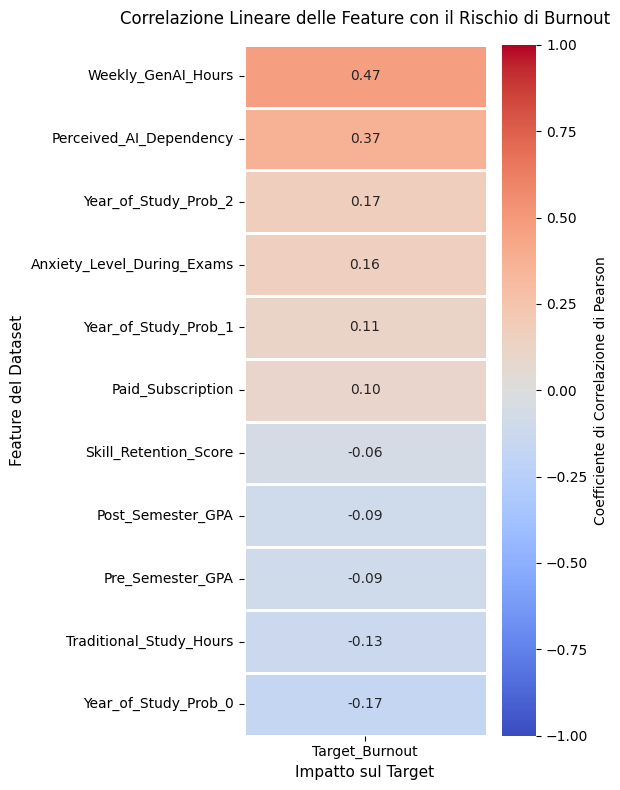

In [28]:

# 1. Creiamo il DataFrame temporaneo unendo Feature e Target
df_corr = X_train.copy()

if y_train.dtype == 'object' or y_train.dtype.name == 'category':
    target_map = {'Low': 0, 'Medium': 1, 'High': 2}
    df_corr['Target_Burnout'] = y_train.map(target_map)
else:
    df_corr['Target_Burnout'] = y_train

# 2. Calcoliamo la matrice ed estraiamo solo la colonna del Target
# Escludiamo l'auto-correlazione del Target con se stesso (che sarebbe 1.0)
correlazione_target = df_corr.corr(method='pearson')[['Target_Burnout']].drop(index='Target_Burnout')

# Ordiniamo i valori in modo decrescente per un impatto visivo immediato
correlazione_target = correlazione_target.sort_values(by='Target_Burnout', ascending=False)

# 3. Disegnamo la heatmap a colonna singola
plt.figure(figsize=(6, 8))
sns.heatmap(
    correlazione_target,
    annot=True,               # Mostra il coefficiente numerico
    fmt=".2f",                # Arrotonda a 2 decimali
    cmap="coolwarm",          # Rosso = aumenta il burnout, Blu = lo diminuisce
    vmin=-1, vmax=1,          # Limiti della scala di correlazione
    linewidths=1,
    cbar_kws={"label": "Coefficiente di Correlazione di Pearson"}
)

# 4. Personalizzazione estetica
plt.title("Correlazione Lineare delle Feature con il Rischio di Burnout", fontsize=12, pad=15)
plt.ylabel("Feature del Dataset", fontsize=11)
plt.xlabel("Impatto sul Target", fontsize=11)

plt.tight_layout()
plt.show()

In [29]:
X_train.describe()

,Pre_Semester_GPA,Weekly_GenAI_Hours,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Year_of_Study_Prob_0,Year_of_Study_Prob_1,Year_of_Study_Prob_2
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,3.146647,8.439752,11.219096,3.509000,4.269450,3.350064,75.760045,0.327375,0.422875,0.249750
std,0.478230,8.293017,5.157899,1.822266,2.142058,0.495032,13.288228,0.067600,0.011863,0.059900
min,1.275000,0.000000,1.000000,1.000000,1.000000,1.190000,13.230000,0.203356,0.402753,0.179264
25%,2.835000,2.390000,7.570000,2.000000,3.000000,3.025000,66.720000,0.292433,0.420467,0.220467
50%,3.211500,5.775000,11.200000,3.000000,4.000000,3.423000,75.970000,0.325282,0.425503,0.242794
75%,3.520000,11.732500,14.720000,5.000000,6.000000,3.749000,85.170000,0.359065,0.431924,0.272631
max,3.998000,40.000000,35.860000,10.000000,10.000000,4.000000,100.000000,0.417983,0.434936,0.371141


**fine preparazione colonne**

inizio addestramento del modello (non ho scalato i valori perchè userò un modello di random forest)

# piano: valutare random forest e xgboost  
fase 1) trovare gli iperparametri migliori per  random forest   (**fatto**)

fase 2) trovare gli iperparametri migliori per  xgboost 

fase 3) addestrare i modelli e confrontarli 

param_grid = {
    'n_estimators': [100, 150, 200 ],    

    'max_depth': [ 10, 20, 30],          # Massima profondità di ogni albero (None = cresce al massimo)

    'min_samples_split': [2, 5, 10],          # Numero minimo di campioni richiesti per sdoppiare un nodo

    'min_samples_leaf': [4],            # Numero minimo di campioni richiesti in una foglia (nodo finale)



# addestramento del random forest con gli iperparametri trovati

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Istanziamo il modello con gli iperparametri ottimi trovati
# Aggiungiamo random_state=42 per garantire la riproducibilità dei risultati
best_rf = RandomForestClassifier(
    criterion='gini',
    max_depth=10,
    min_samples_leaf=4,
    min_samples_split=2,
    n_estimators=100,
    random_state=42,
    n_jobs=-1  # Sfrutta tutti i core della CPU per velocizzare l'addestramento
)

# 2. Addestriamo il modello sul set di train (che include il tuo Target Encoding)
best_rf.fit(X_train, y_train)

# 3. Valutiamo le performance sul set di test per verificare che non ci sia overfitting
y_pred = best_rf.predict(X_test)

# Stampiamo i risultati finali
print(f"Accuratezza finale sul Test Set: {accuracy_score(y_test, y_pred):.4f}\n")
print("--- Report di Classificazione Completo ---")
print(classification_report(y_test, y_pred))

Accuratezza finale sul Test Set: 0.5329

--- Report di Classificazione Completo ---
              precision    recall  f1-score   support

           0       0.54      0.50      0.52      3274
           1       0.49      0.61      0.54      4229
           2       0.66      0.45      0.54      2497

    accuracy                           0.53     10000
   macro avg       0.56      0.52      0.53     10000
weighted avg       0.55      0.53      0.53     10000



**Con un'accuratezza del 53.05% su un problema a tre classi (casuale su tre classi = 33%), il modello ha catturato dei pattern utili, ma i dati mostrano che fa fatica a distinguere nettamente tra le classi adiacenti.**

**burnout High: ha una precision molto alta (66%) ma una recall bassa (45%). Questo significa che quando il modello si sbilancia a dire "Rischio Alto", ci indovina quasi sempre, ma si perde per strada più della metà dei veri casi ad alto rischio**



ricorda il map 
'Low': 0, 'Medium': 1, 'High': 2

In [31]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

    # # Poiché abbiamo un problema a 3 classi (Low, Medium, High), impostiamo l'objective corretto
    # xgb_base = XGBClassifier(
    #     objective='multi:softprob', 
    #     random_state=42, 
    #     use_label_encoder=False, 
    #     eval_metric='mlogloss'
    # )

    # # 2. Definiamo la griglia degli iperparametri per XGBoost
    # # Questa selezione è ottimizzata per trovare un buon bilanciamento senza andare in overfitting
    # param_grid = {
    #     'n_estimators': [100, 150,  200],           # Numero di alberi sequenziali
    #     'max_depth': [3, 5, 7],               # Profondità degli alberi (XGBoost preferisce alberi più bassi di RF)
    #     'learning_rate': [0.01, 0.05, 0.1],    # Passo di apprendimento (regola l'impatto di ogni nuovo albero)
    #     'subsample': [0.6 ,0.8],              # Percentuale di dati da campionare per ogni albero
    #     'colsample_bytree': [0,4, 0.7]        # Percentuale di feature da campionare per ogni albero
    # }

    # # 3. Configuriama la Grid Search con 5-Fold Cross-Validation
    # grid_search_xgb = GridSearchCV(
    #     estimator=xgb_base,
    #     param_grid=param_grid,
    #     cv=5,                                 # Sdoppia il train in 5 parti per convalidare i punteggi
    #     scoring='accuracy',                   # Puoi usare 'f1_macro' se le classi sono sbilanciate
    #     n_jobs=-1,                            # Sfrutta tutti i core della CPU in parallelo
    #     verbose=2                             # Mostra i log dell'avanzamento dei calcoli
    # )

    # # 4. Avviamo l'addestramento sui dati
    # # NOTA: Assicurati che X_train contenga solo colonne numeriche (dopo i tuoi passaggi di Target Encoding)
    # grid_search_xgb.fit(X_train, y_train)


    # # ==============================================================================
    # # STAMPA DEI RISULTATI
    # # ==============================================================================
    # print("\n--- Risultati della Grid Search con XGBoost ---")
    # print(f"Miglior Accuratezza in Cross-Validation: {grid_search_xgb.best_score_:.4f}")
    # print("Migliori Iperparametri Trovati:")
    # for param, value in grid_search_xgb.best_params_.items():
    #     print(f"  -> {param}: {value}")

    # # 5. Estraiamo il modello migliore e già pronto
    # best_xgb_model = grid_search_xgb.best_estimator_

In [32]:
lista = y_test.unique()
print(lista)  # l'ordine è corretto !! (controllato)

[1 0 2]


In [33]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
best_xgb = XGBClassifier(
    objective='multi:softprob',     # Specifica che è un problema multi-classe probabilistico
    eval_metric='mlogloss',         # Metrica di valutazione interna
    colsample_bytree=0.7,           # Iperparametri ottimi trovati dalla tua Grid Search
    learning_rate=0.05,
    max_depth=5,
    n_estimators=100,
    subsample=0.6,
    random_state=42,                # Per rendere i risultati riproducibili
    n_jobs=-1                       # Sfrutta al massimo la CPU
)

best_xgb.fit(X_train, y_train)

y_pred_xgb = best_xgb.predict(X_test)

# Definizione dei nomi delle classi per rendere il report auto-esplicativo
target_names = ['Low (0)', 'Medium (1)', 'High (2)']

print(f"Accuratezza finale di XGBoost sul Test Set: {accuracy_score(y_test, y_pred_xgb):.4f}\n")
print("--- REPORT DI CLASSIFICAZIONE COMPLETO (XGBOOST) ---")
print(classification_report(y_test, y_pred_xgb, target_names=target_names))

Accuratezza finale di XGBoost sul Test Set: 0.5334

--- REPORT DI CLASSIFICAZIONE COMPLETO (XGBOOST) ---
              precision    recall  f1-score   support

     Low (0)       0.55      0.47      0.51      3274
  Medium (1)       0.49      0.63      0.55      4229
    High (2)       0.67      0.45      0.54      2497

    accuracy                           0.53     10000
   macro avg       0.57      0.52      0.53     10000
weighted avg       0.55      0.53      0.53     10000



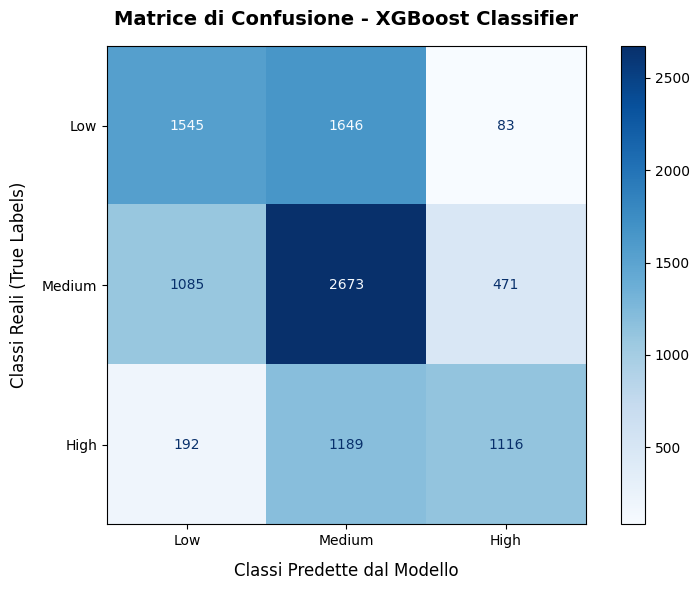

In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Calcoliamo la matrice di confusione numerica pura
cm = confusion_matrix(y_test, y_pred_xgb)

# 2. Configuriamo l'aspetto grafico della matrice
fig, ax = plt.subplots(figsize=(8, 6))

# Definiamo i nomi esatti delle classi
target_names = ['Low', 'Medium', 'High']

# Creiamo il visualizzatore grafico
visualizzatore_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=target_names
)

# 3. Disegniamo la matrice sul grafico
visualizzatore_cm.plot(
    ax=ax, 
    cmap='Blues',         # Sfumatura di blu elegante (i valori alti saranno blu scuro)
    values_format='d'      # Mostra i numeri come interi puri (senza decimali strani)
)

# 4. Personalizzazione estetica dei titoli e delle etichette
plt.title("Matrice di Confusione - XGBoost Classifier", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Classi Predette dal Modello", fontsize=12, labelpad=10)
plt.ylabel("Classi Reali (True Labels)", fontsize=12, labelpad=10)

# Rimuoviamo la griglia di sfondo bianca che potrebbe sporcare i quadrati
ax.grid(False)

plt.tight_layout()
plt.show()